In [4]:
# Import NumPy for numerical operations
import numpy as np

# Import Pandas for data manipulation and analysis
import pandas as pd

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Seaborn for statistical visualizations
import seaborn as sns


# Import tools for splitting data and performing cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# Import tools for preprocessing columns and creating ML pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import tools for scaling numerical data and encoding categorical data
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import tool for handling missing values
from sklearn.impute import SimpleImputer


# Import Linear Regression and regularized regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso


# Import evaluation metrics for measuring model performance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Ignore warning messages to keep the notebook output clean
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("House_Price.csv")

In [6]:
df.head()

,area,bedrooms,bathrooms,stories,parking,age,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,price
0,1360.0,3,3.0,2,1,3,no,no,yes,no,no,no,furnished,19173000
1,5890.0,2,2.0,2,2,8,yes,no,no,no,no,yes,semi-furnished,54850000
2,5726.0,2,1.0,2,2,21,yes,yes,no,no,no,no,unfurnished,55092000
3,5691.0,3,3.0,2,0,23,yes,yes,no,no,no,no,semi-furnished,50998000
4,4272.0,3,3.0,1,3,22,yes,yes,no,no,yes,yes,unfurnished,42842000


In [7]:
df.tail()

,area,bedrooms,bathrooms,stories,parking,age,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,price
598,5801.0,5,4.0,1,0,9,yes,yes,no,no,no,no,semi-furnished,55635000
599,2714.0,2,2.0,3,1,16,no,no,yes,no,no,yes,unfurnished,27224000
600,3671.0,4,4.0,2,0,28,yes,no,no,yes,yes,no,semi-furnished,37719000
601,974.0,4,4.0,2,0,16,no,no,yes,no,no,no,unfurnished,14632000
602,2541.0,4,4.0,2,1,25,no,yes,no,no,no,no,semi-furnished,27936000


In [8]:
#Random Rows

df.sample(5, random_state=42) 

,area,bedrooms,bathrooms,stories,parking,age,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,price
110,5098.0,5,4.0,2,1,26,yes,yes,no,no,no,yes,unfurnished,48623000
527,3940.0,4,4.0,3,2,14,yes,no,no,no,yes,yes,semi-furnished,43036000
567,1232.0,2,2.0,3,1,29,yes,no,no,no,yes,no,unfurnished,15273000
77,3842.0,3,2.0,3,2,7,no,no,yes,no,no,no,unfurnished,36815000
181,4081.0,4,4.0,2,0,15,no,no,no,yes,no,no,furnished,41120000


In [9]:
df.shape

(603, 14)

In [10]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'age',
       'mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus', 'price'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area              597 non-null    float64
 1   bedrooms          603 non-null    int64  
 2   bathrooms         597 non-null    float64
 3   stories           603 non-null    int64  
 4   parking           603 non-null    int64  
 5   age               603 non-null    int64  
 6   mainroad          603 non-null    str    
 7   guestroom         603 non-null    str    
 8   basement          603 non-null    str    
 9   hotwaterheating   603 non-null    str    
 10  airconditioning   597 non-null    str    
 11  prefarea          603 non-null    str    
 12  furnishingstatus  597 non-null    str    
 13  price             603 non-null    int64  
dtypes: float64(2), int64(5), str(7)
memory usage: 66.1 KB


In [12]:
df.describe()

,area,bedrooms,bathrooms,stories,parking,age,price
count,597.000000,603.000000,597.000000,603.000000,603.000000,603.000000,6.030000e+02
mean,3298.659966,2.978441,2.705193,1.996683,1.489221,15.172471,3.396919e+07
std,1554.751932,1.435617,1.206883,0.835262,1.140234,8.939819,1.325093e+07
min,504.000000,1.000000,1.000000,1.000000,0.000000,0.000000,7.552000e+06
25%,1995.000000,2.000000,2.000000,1.000000,0.000000,7.000000,2.231350e+07
50%,3349.000000,3.000000,3.000000,2.000000,1.000000,16.000000,3.409700e+07
75%,4590.000000,4.000000,4.000000,3.000000,3.000000,23.000000,4.451800e+07
max,5996.000000,5.000000,4.000000,3.000000,3.000000,30.000000,6.016100e+07


In [13]:
df.describe(include="object")

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,603,603,603,603,597,603,597
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,429,454,379,542,327,395,264


In [14]:
df.isnull().sum()

area                6
bedrooms            0
bathrooms           6
stories             0
parking             0
age                 0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     6
prefarea            0
furnishingstatus    6
price               0
dtype: int64

In [15]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

area                0.995025
bathrooms           0.995025
airconditioning     0.995025
furnishingstatus    0.995025
bedrooms            0.000000
stories             0.000000
age                 0.000000
parking             0.000000
mainroad            0.000000
guestroom           0.000000
hotwaterheating     0.000000
basement            0.000000
prefarea            0.000000
price               0.000000
dtype: float64

In [16]:
df.duplicated().sum()

np.int64(3)

In [17]:
df = df.drop_duplicates().reset_index(drop=True)


In [18]:
df.shape

(600, 14)

In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
## Remove Duplicates
df = df.drop_duplicates().reset_index(drop=True)

In [22]:
df.shape

(600, 14)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 mainroad
mainroad
yes    428
no     172
Name: count, dtype: int64

 guestroom
guestroom
no     452
yes    148
Name: count, dtype: int64

 basement
basement
no     377
yes    223
Name: count, dtype: int64

 hotwaterheating
hotwaterheating
no     540
yes     60
Name: count, dtype: int64

 airconditioning
airconditioning
no     325
yes    269
NaN      6
Name: count, dtype: int64

 prefarea
prefarea
no     392
yes    208
Name: count, dtype: int64

 furnishingstatus
furnishingstatus
semi-furnished    262
unfurnished       174
furnished         158
NaN                 6
Name: count, dtype: int64


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,594.0,3.303222e+03,1.555361e+03,504.0,1995.0,3359.0,4595.25,5996.0
bedrooms,600.0,2.973333e+00,1.437382e+00,1.0,2.0,3.0,4.00,5.0
bathrooms,594.0,2.698653e+00,1.206404e+00,1.0,2.0,3.0,4.00,4.0
stories,600.0,1.996667e+00,8.373515e-01,1.0,1.0,2.0,3.00,3.0
parking,600.0,1.495000e+00,1.139652e+00,0.0,0.0,1.0,3.00,3.0
age,600.0,1.513333e+01,8.937675e+00,0.0,7.0,16.0,23.00,30.0
price,600.0,3.400522e+07,1.325732e+07,7552000.0,22318750.0,34144500.0,44554750.00,60161000.0


In [26]:
df["price"].describe()

count    6.000000e+02
mean     3.400522e+07
std      1.325732e+07
min      7.552000e+06
25%      2.231875e+07
50%      3.414450e+07
75%      4.455475e+07
max      6.016100e+07
Name: price, dtype: float64

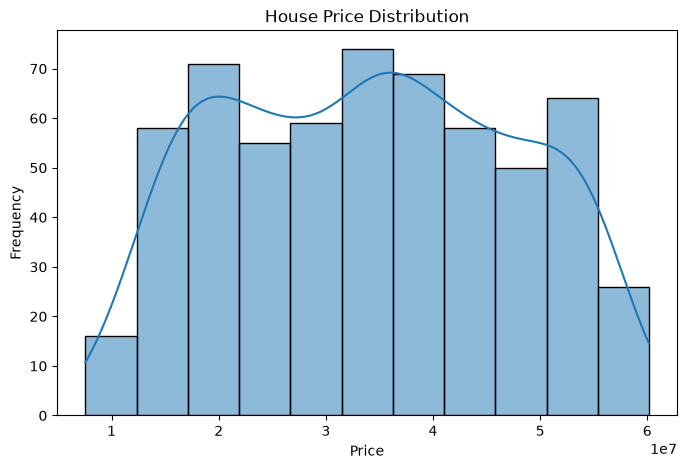

In [27]:
##Target Distribution
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="price", kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

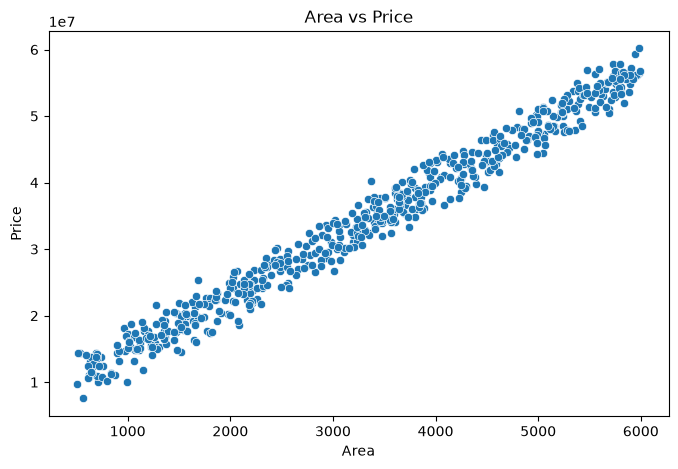

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="area",
    y="price"
)

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

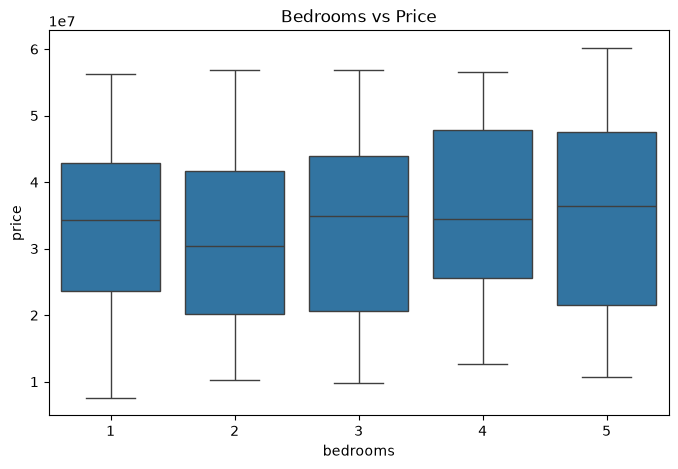

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.title("Bedrooms vs Price")

plt.show()

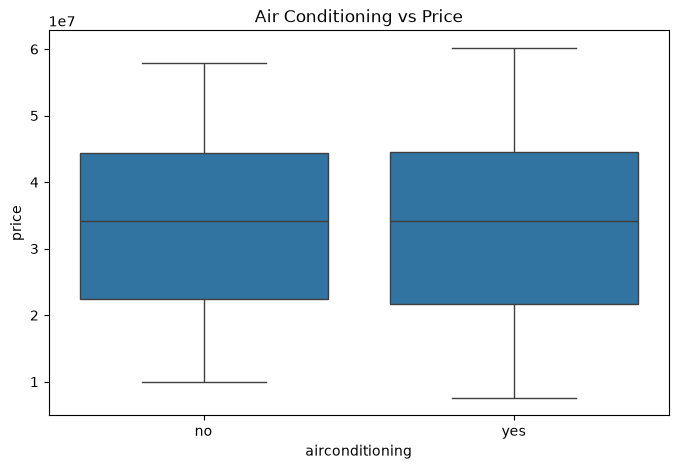

In [30]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="airconditioning",
    y="price"
)

plt.title("Air Conditioning vs Price")

plt.show()


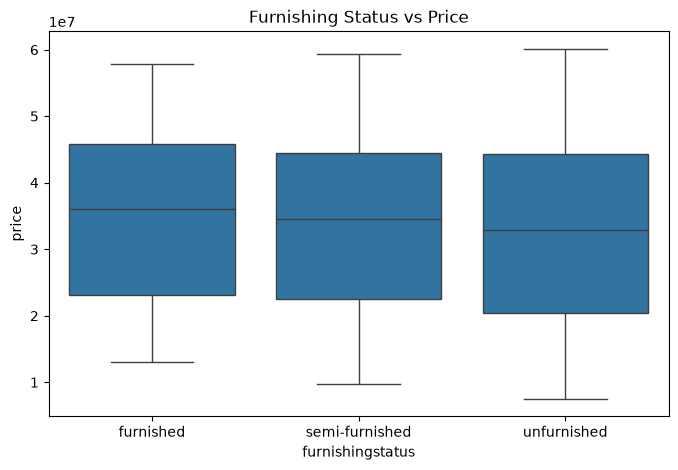

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="furnishingstatus",
    y="price"
)

plt.title("Furnishing Status vs Price")

plt.show()

In [32]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numerical_columns].corr()

correlation


,area,bedrooms,bathrooms,stories,parking,age,price
area,1.000000,-0.016281,-0.040968,-0.005235,-0.019768,0.068034,0.989089
bedrooms,-0.016281,1.000000,0.899977,-0.027815,-0.049000,-0.019085,0.082528
bathrooms,-0.040968,0.899977,1.000000,0.001831,-0.045382,-0.002830,0.058312
stories,-0.005235,-0.027815,0.001831,1.000000,-0.014013,0.078803,0.008190
parking,-0.019768,-0.049000,-0.045382,-0.014013,1.000000,-0.043532,-0.000389
age,0.068034,-0.019085,-0.002830,0.078803,-0.043532,1.000000,0.033865
price,0.989089,0.082528,0.058312,0.008190,-0.000389,0.033865,1.000000


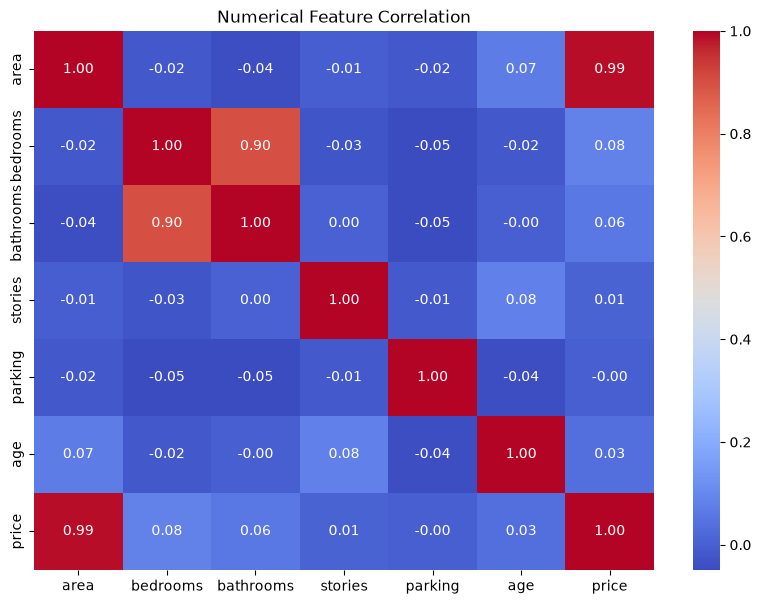

In [34]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")

plt.show()

In [35]:
X = df.drop("price", axis=1)

y = df["price"]

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600, 13)
y shape: (600,)


In [37]:
X.head()

,area,bedrooms,bathrooms,stories,parking,age,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,1360.0,3,3.0,2,1,3,no,no,yes,no,no,no,furnished
1,5890.0,2,2.0,2,2,8,yes,no,no,no,no,yes,semi-furnished
2,5726.0,2,1.0,2,2,21,yes,yes,no,no,no,no,unfurnished
3,5691.0,3,3.0,2,0,23,yes,yes,no,no,no,no,semi-furnished
4,4272.0,3,3.0,1,3,22,yes,yes,no,no,yes,yes,unfurnished


In [38]:
y.head()

0    19173000
1    54850000
2    55092000
3    50998000
4    42842000
Name: price, dtype: int64

In [39]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [40]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [41]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (420, 13)
Validation: (90, 13)
Testing: (90, 13)


In [42]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'age']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [43]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [44]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [45]:
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [46]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [47]:
SimpleImputer(strategy="most_frequent")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [48]:
OneHotEncoder()

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequent

In [49]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [50]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [51]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'airconditioning','prefarea', 'furnishingstatus']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [52]:
y_train_pred = linear_model.predict(X_train)

In [53]:
y_val_pred = linear_model.predict(X_val)

In [54]:
y_test_pred = linear_model.predict(X_test)

In [55]:
def evaluate_model(y_actual, y_pred):
    
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)
    
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

In [56]:
evaluate_model(y_train, y_train_pred)

MAE : 981473.9793763001
MSE : 2734017058614.551
RMSE: 1653486.3345714565
R²  : 0.9840895892145018


In [57]:
evaluate_model(y_val, y_val_pred)

MAE : 1043412.8322979801
MSE : 2459344878646.9126
RMSE: 1568229.8551701254
R²  : 0.9864884707113779


In [58]:
evaluate_model(y_test, y_test_pred)

MAE : 883532.0875485383
MSE : 1143651686058.706
RMSE: 1069416.5166382582
R²  : 0.9938186616105853


In [59]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

results.head(10)

,Actual,Predicted
86,43152000,4.294922e+07
506,17058000,1.678972e+07
332,38621000,3.842002e+07
559,30733000,3.120529e+07
117,56264000,5.421257e+07
234,47096000,4.778582e+07
368,16019000,1.748386e+07
81,20079000,1.857649e+07
584,20632000,2.115055e+07
494,26702000,2.610007e+07


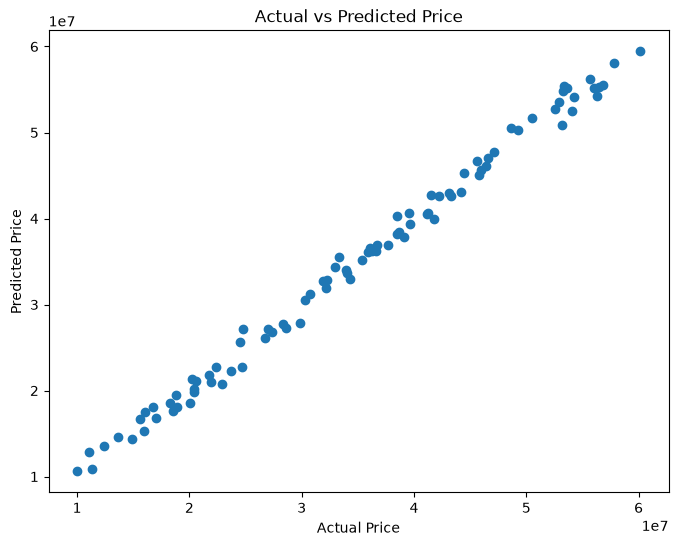

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [61]:
residuals = y_test - y_test_pred

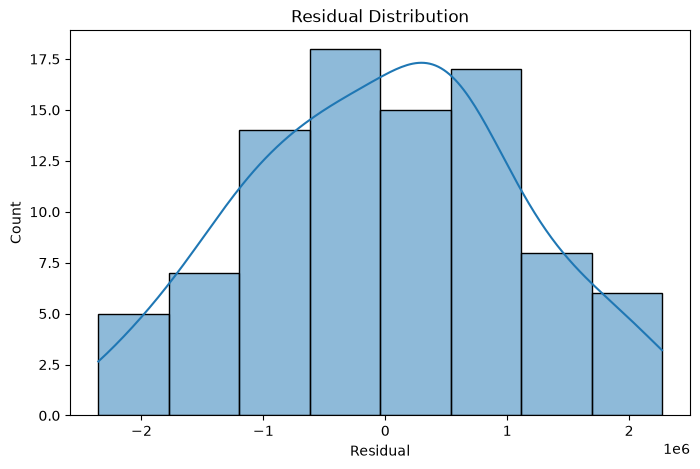

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual")

plt.show()


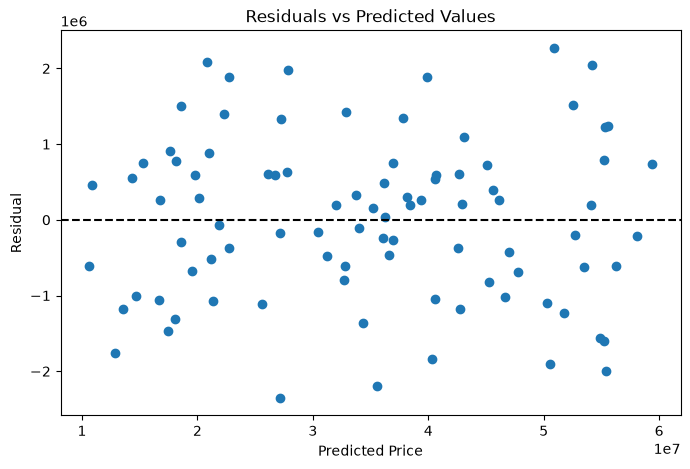

In [63]:
plt.figure(figsize=(8,5))

plt.scatter(y_test_pred, residuals)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted Values")

plt.show()

In [64]:
regressor = linear_model.named_steps["regressor"]

In [65]:
regressor.intercept_

np.float64(34107155.54914598)

In [66]:
regressor.coef_

array([12969268.49236496,   751806.80525966,   591604.05853073,
         195414.38880982,   322721.30551458,  -417507.40692225,
        -141939.41298242,   141939.41298242,  -252703.53145969,
         252703.53145969,  -316543.61001299,   316543.61001299,
          63545.06835416,   -63545.06835416,  -301472.2281905 ,
         301472.2281905 ,  -314055.43670371,   314055.43670371,
         310715.60021742,  -102511.32238069,  -208204.27783673])

In [67]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'age',
       'mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [68]:
feature_names = (
    linear_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [69]:
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients


,Feature,Coefficient
0,num__area,1.296927e+07
1,num__bedrooms,7.518068e+05
2,num__bathrooms,5.916041e+05
4,num__parking,3.227213e+05
11,cat__basement_yes,3.165436e+05
17,cat__prefarea_yes,3.140554e+05
18,cat__furnishingstatus_furnished,3.107156e+05
15,cat__airconditioning_yes,3.014722e+05
9,cat__guestroom_yes,2.527035e+05
3,num__stories,1.954144e+05


In [70]:
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²  :", train_r2)
print("Validation R²:", val_r2)
print("Testing R²   :", test_r2)

Training R²  : 0.9840895892145018
Validation R²: 0.9864884707113779
Testing R²   : 0.9938186616105853


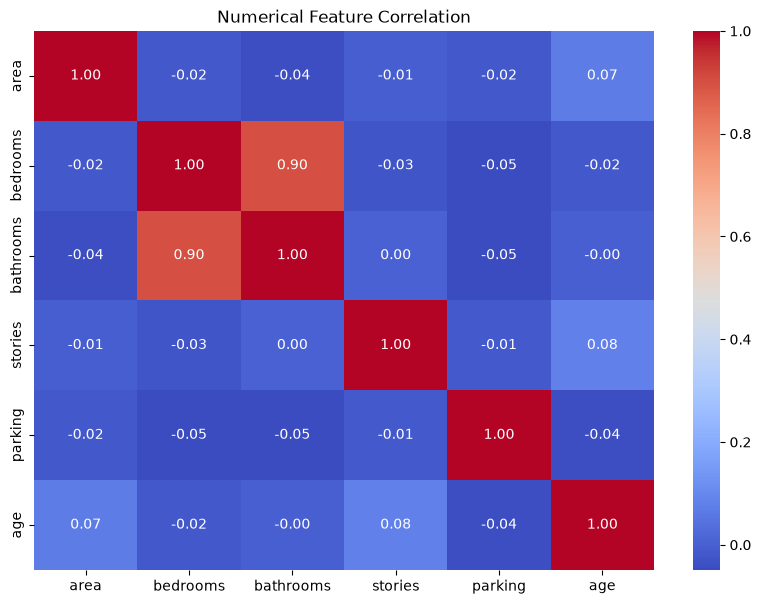

In [71]:
numerical_df = df[numerical_features]

plt.figure(figsize=(10,7))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")

plt.show()

In [72]:
cv_scores = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

In [73]:
print("CV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())


CV Scores: [0.9921874  0.95336721 0.98479476 0.99333702 0.98857152]
Mean CV R²: 0.9824515816253065
Std CV R²: 0.014846710233502331


In [74]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

In [75]:
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'airconditioning','prefarea', 'furnishingstatus']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [77]:
ridge_val_pred = ridge_model.predict(X_val)

In [78]:
evaluate_model(y_val, ridge_val_pred)

MAE : 1043274.7626822246
MSE : 2456485006312.617
RMSE: 1567317.7745156267
R²  : 0.9865041827203532


In [79]:
alphas = [0.01, 0.1, 1, 10, 100]

In [80]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in alphas:
    
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=alpha))
    ])
    
    model.fit(X_train, y_train)
    
    val_pred = model.predict(X_val)
    
    val_r2 = r2_score(y_val, val_pred)
    val_rmse = np.sqrt(
        mean_squared_error(y_val, val_pred)
    )
    
    ridge_results.append({
        "Alpha": alpha,
        "Validation_R2": val_r2,
        "Validation_RMSE": val_rmse
    })

ridge_results = pd.DataFrame(ridge_results)

ridge_results

,Alpha,Validation_R2,Validation_RMSE
0,0.01,0.986489,1.568217e+06
1,0.10,0.986491,1.568105e+06
2,1.00,0.986504,1.567318e+06
3,10.00,0.986100,1.590633e+06
4,100.00,0.948616,3.058234e+06


In [81]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.01, max_iter=10000))
])

In [82]:
lasso_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'airconditioning','prefarea', 'furnishingstatus']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [83]:
lasso_val_pred = lasso_model.predict(X_val)


In [84]:
evaluate_model(y_val, lasso_val_pred)

MAE : 1043412.839055337
MSE : 2459344868467.5186
RMSE: 1568229.851924621
R²  : 0.9864884707673031


In [85]:
linear_val_pred = linear_model.predict(X_val)
ridge_val_pred = ridge_model.predict(X_val)
lasso_val_pred = lasso_model.predict(X_val)

In [86]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    
    "MAE": [
        mean_absolute_error(y_val, linear_val_pred),
        mean_absolute_error(y_val, ridge_val_pred),
        mean_absolute_error(y_val, lasso_val_pred)
    ],
    
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, linear_val_pred)),
        np.sqrt(mean_squared_error(y_val, ridge_val_pred)),
        np.sqrt(mean_squared_error(y_val, lasso_val_pred))
    ],
    
    "R2": [
        r2_score(y_val, linear_val_pred),
        r2_score(y_val, ridge_val_pred),
        r2_score(y_val, lasso_val_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1.043413e+06,1.568230e+06,0.986488
1,Ridge Regression,1.043275e+06,1.567318e+06,0.986504
2,Lasso Regression,1.043413e+06,1.568230e+06,0.986488


In [87]:
final_model = ridge_model

In [88]:
X_development = pd.concat([
    X_train,
    X_val
])

y_development = pd.concat([
    y_train,
    y_val
])


In [89]:
final_model.fit(
    X_development,
    y_development
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'airconditioning','prefarea', 'furnishingstatus']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This 

In [90]:
final_predictions = final_model.predict(X_test)

In [91]:
evaluate_model(
    y_test,
    final_predictions
)

MAE : 874722.5528817709
MSE : 1116967331868.7131
RMSE: 1056866.7521824655
R²  : 0.9939628882356688


In [92]:
final_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": final_predictions
})

final_results.head(10)

,Actual,Predicted
86,43152000,4.280526e+07
506,17058000,1.670490e+07
332,38621000,3.819004e+07
559,30733000,3.107863e+07
117,56264000,5.412929e+07
234,47096000,4.760475e+07
368,16019000,1.753665e+07
81,20079000,1.871152e+07
584,20632000,2.102009e+07
494,26702000,2.603417e+07


In [93]:
new_house = pd.DataFrame({
    "area": [5000],
    "bedrooms": [4],
    "bathrooms": [3],
    "stories": [2],
    "parking": [2],
    "age": [5],
    "mainroad": ["yes"],
    "guestroom": ["no"],
    "basement": ["no"],
    "hotwaterheating": ["no"],
    "airconditioning": ["yes"],
    "prefarea": ["yes"],
    "furnishingstatus": ["furnished"]
})

In [94]:
predicted_price = final_model.predict(new_house)

print(
    "Predicted House Price:",
    predicted_price[0]
)

Predicted House Price: 50490545.28908195


In [95]:
import joblib

joblib.dump(
    final_model,
    "house_price_model.pkl"
)

['house_price_model.pkl']

In [96]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)

In [97]:
loaded_model.predict(new_house)

array([50490545.28908195])